# Inside VascX — tracing one artery, stage by stage

**Work in progress**, and deliberately small: **one photograph, one class, no adapter.** HRF's
`01_h`, arteries only, the expert's map beside VascX's own — enough to watch the machinery and not
so much that a plot is unreadable.

Everything below calls **VascX's own objects directly**. `src/biomarkers/vascx.py` is not imported
except to reach the upstream classes it loads; no benchmark, no canonical names, no unit
conversion. What you see is what VascX computes.

**Using this with a debugger.** Every stage is a separate cell that reads one property of a
`VesselTreeLayer`, and each property is `@cached_property` — so it runs **once**, the first time
you touch it, and is silent afterwards. To step into one, set the breakpoint *before* the cell that
first reads it:

| Breakpoint here | To watch |
| --- | --- |
| `vascx/shared/masks.py` → `fill_small_holes` | stage 1, the hole filling |
| `vascx/shared/graph.py` → `make_graph` | stage 3, skeleton to graph, and the degree-2 collapse |
| `vascx/fundus/layer.py` → `make_trees` | stage 4, one tree per connected component |
| `vascx/shared/graph.py` → `correct_digraph` | stage 5, spur removal |
| `vascx/shared/splines.py` → `SplineInterpolation.__init__` | stage 7, the spline fit |
| `vascx/fundus/layer.py` → `_build_vessels` | stage 8, segments merged into vessels |
| `vascx/fundus/features/tortuosity.py` → `_compute_for_segment` | the tortuosity measures |

In VS Code, "Debug Cell" on the cell that first touches the property; `justMyCode` must be **off**
or you will step over all of the above, since none of it is ours.

The stage numbering is the one in
[vessel tracing](../../docs/biomarkers/vessel-tracing.md) §3.2, which this notebook is the
illustrated version of.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


def repository() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").is_dir():
            return candidate
    raise RuntimeError(f"nothing above {Path.cwd()} looks like the fundus-atlas repository")


ROOT = repository()
sys.path.insert(0, str(ROOT / "src"))

from biomarkers.utils import catalogue as biomarkers  # noqa: E402
from upstreams import vascx  # noqa: E402

vascx.on_path()
from rtnls_enface.disc import OpticDisc  # noqa: E402

#: VascX's own classes, reached through the upstream module so the clone is on the path. This is
#: the only thing this notebook borrows from `src/` — everything after it is VascX's.
Retina, VesselTreeLayer, FundusVesselsLayer, feature_sets = biomarkers.load("vascx")._loaded()

KEY = "01_h"
STORE = ROOT / ".atlas_data" / "hrf" / "native"
PREDICTED = ROOT / ".atlas_runs" / "av" / "vascx-artery-vein" / "hrf"
UM_PER_PX = 4.9802  # HRF, inferred by this repository rather than published


def mask(path: Path) -> np.ndarray:
    return np.array(Image.open(path)) > 0


EXPERT = mask(STORE / "artery" / f"{KEY}.png")
VASCX = mask(PREDICTED / f"{KEY}-artery.png")
FOV = mask(STORE / "fov" / f"{KEY}.png")
PHOTO = np.array(Image.open(STORE / "images" / f"{KEY}.png").convert("RGB"))
SIDE = EXPERT.shape[0]

print(f"{KEY}: {SIDE}×{SIDE} px at {UM_PER_PX} µm/px")
print(f"  expert artery  {EXPERT.sum():>8,} px")
print(f"  VascX artery   {VASCX.sum():>8,} px")

01_h: 3270×3270 px at 4.9802 µm/px
  expert artery   418,287 px
  VascX artery    301,357 px


## 0. The optic disc, and the two layers

VascX measures everything from the optic disc, and HRF's store carries none — so it comes from
VascX's own disc model, run once. **The same disc goes to both layers**, so nothing below differs
because of it.

`build_layer` is the whole of the setup: a `Retina` holding one `VesselTreeLayer`. Note the
`OpticDisc` rebuilt on the last line — without it every disc-anchored measurement fails, which is
the defect on [the project page](../../docs/projects/vascx.md) §8.1.

In [2]:
from models.utils import catalogue as models  # noqa: E402
import torch  # noqa: E402


def find_disc(image: np.ndarray) -> tuple[float, float, float]:
    """The optic disc as a centre and a radius, from VascX's own disc model."""
    model = models.load("vascx-disc")
    small = np.array(Image.fromarray(image).resize((model.grid, model.grid), Image.BILINEAR))
    found = model.outline(torch.stack([model.prepare(small)]), [image.shape[0]])[0]
    model.release()
    rows, columns = np.nonzero(found.masks["disc"])
    return (
        float(columns.mean()),
        float(rows.mean()),
        float(np.sqrt(found.masks["disc"].sum() / np.pi)),
    )


DISC_X, DISC_Y, DISC_R = find_disc(PHOTO)
print(f"disc at ({DISC_X:.0f}, {DISC_Y:.0f}), radius {DISC_R:.0f} px")


def disc_mask() -> np.ndarray:
    rows, columns = np.mgrid[:SIDE, :SIDE]
    return ((columns - DISC_X) ** 2 + (rows - DISC_Y) ** 2 <= DISC_R**2).astype(np.uint8)


def build_layer(artery: np.ndarray) -> object:
    """One artery mask, as a VascX `VesselTreeLayer`. No adapter, no benchmark."""
    disc = disc_mask()
    retina = Retina(
        disc_path_or_mask=disc,
        layers={
            "arteries": VesselTreeLayer("arteries", artery, color=(1, 0, 0)),
            "vessels": FundusVesselsLayer(name="vessels", mask=artery),
        },
        resolution=(SIDE, SIDE),
        mm_per_pixel=UM_PER_PX / 1000.0,
        # VascX scales several features by the disc-to-fovea distance. HRF is disc-centred-ish and
        # the fovea is not annotated, so this is a stated convention, not a measurement.
        fovea_location=(SIDE * 0.2, SIDE * 0.5),
        roi_mask=FOV.astype(np.uint8),
    )
    # The 1024-pixel disc defect: without this, every disc-anchored feature fails silently.
    retina.disc = OpticDisc(disc, fundus=retina, size=SIDE)
    return retina.layers["arteries"]


LAYERS = {"expert": build_layer(EXPERT), "vascx": build_layer(VASCX)}
print("two layers built — nothing traced yet, every stage below is lazy")

/Users/staskh/Pheno/fundus-atlas/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/staskh/Pheno/fundus-atlas/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1643: FutureWarning: `torch.jit.interface` is deprecated. Please use `torch.compile` instead.
  warnings.warn(


/Users/staskh/Pheno/fundus-atlas/.venv/lib/python3.12/site-packages/albumentations/core/composition.py:250: UserWarning: Got processor for keypoints, but no transform to process it.
  self._set_keys()


/Users/staskh/Pheno/fundus-atlas/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


/Users/staskh/Pheno/fundus-atlas/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:362.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)


/Users/staskh/Pheno/fundus-atlas/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:362.)
  out[idx_zm] += p


disc at (2523, 1625), radius 184 px


two layers built — nothing traced yet, every stage below is lazy


## 1. Mask → binary

`binarize_and_fill`: threshold at 0.5, then `fill_small_holes(area_threshold=25)`, which fills a
background region **only where it is fully enclosed** by vessel and smaller than 25 pixels.

Touching `.binary` is what runs it.

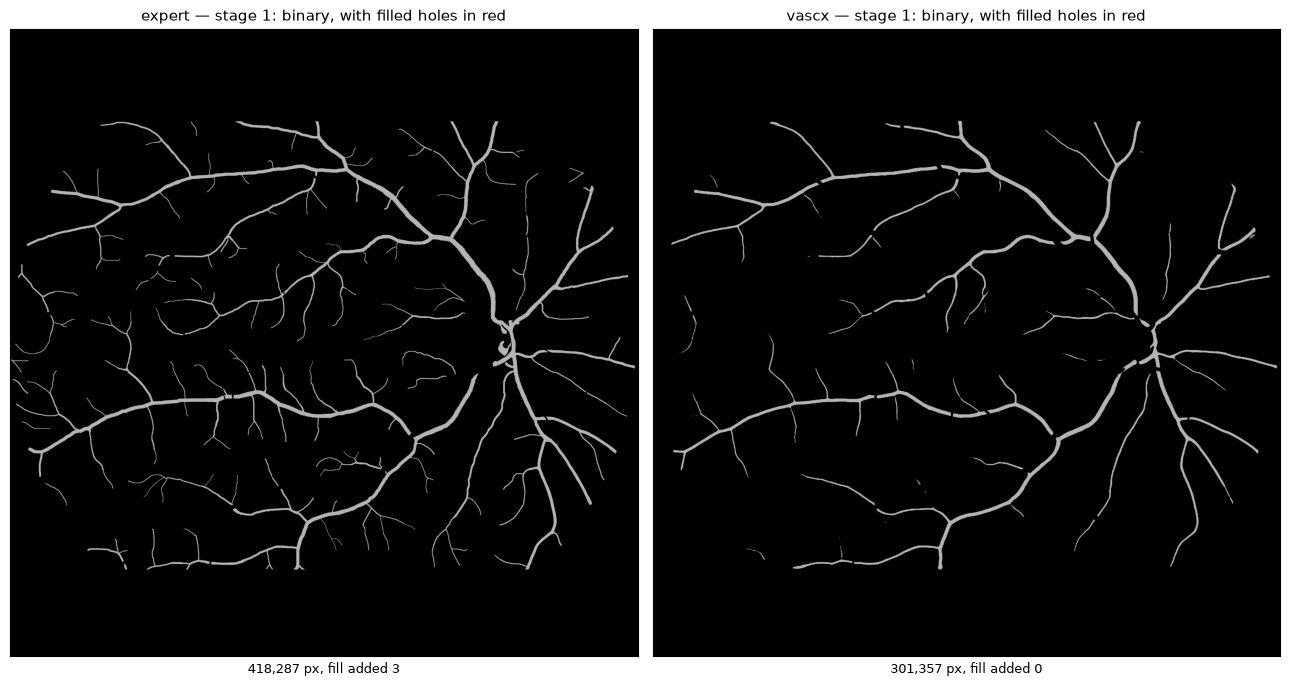

In [3]:
def panels(title: str, draw, zoom=None, size=(13, 6.6)):
    """The same view of both layers, side by side. `draw(axis, name, layer)` does one panel."""
    figure, axes = plt.subplots(1, 2, figsize=size)
    for axis, (name, layer) in zip(axes, LAYERS.items()):
        draw(axis, name, layer)
        axis.set_title(f"{name} — {title}", fontsize=11)
        if zoom:
            (x0, x1), (y0, y1) = zoom
            axis.set_xlim(x0, x1)
            axis.set_ylim(y1, y0)
        axis.set_xticks([])
        axis.set_yticks([])
    figure.tight_layout()
    plt.show()


def show_binary(axis, name, layer):
    raw = EXPERT if name == "expert" else VASCX
    filled = np.asarray(layer.binary) > 0
    picture = np.zeros((SIDE, SIDE, 3), dtype=np.uint8)
    picture[raw] = (180, 180, 180)
    picture[filled & ~raw] = (255, 0, 0)  # what the fill added
    axis.imshow(picture)
    axis.set_xlabel(f"{raw.sum():,} px, fill added {int((filled & ~raw).sum()):,}", fontsize=9)


panels("stage 1: binary, with filled holes in red", show_binary)

## 2. Skeleton

`skimage.morphology.skeletonize` on the filled binary. This is the centreline every later stage
works on — the mask itself is only consulted again for diameters.

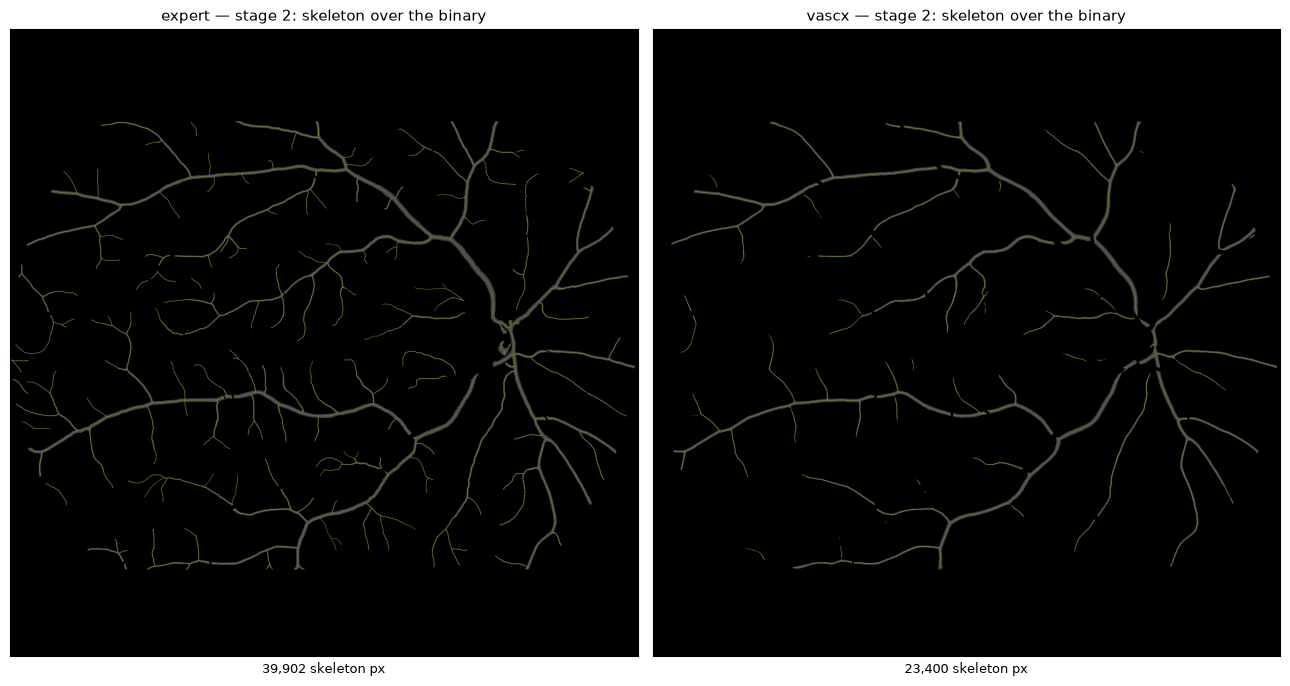

In [4]:
def show_skeleton(axis, name, layer):
    picture = np.zeros((SIDE, SIDE, 3), dtype=np.uint8)
    picture[np.asarray(layer.binary) > 0] = (70, 70, 70)
    picture[layer.skeleton] = (255, 255, 0)
    axis.imshow(picture)
    axis.set_xlabel(f"{int(layer.skeleton.sum()):,} skeleton px", fontsize=9)


panels("stage 2: skeleton over the binary", show_skeleton)

## 3. Graph

`sknw.build_sknw` turns the skeleton into a graph — one edge per run of pixels between two
junctions — and then every node of degree 2 is collapsed, so an edge runs from one junction or
endpoint to the next.

**Each edge is one `Segment`.** This is the unit a per-segment biomarker is computed on.

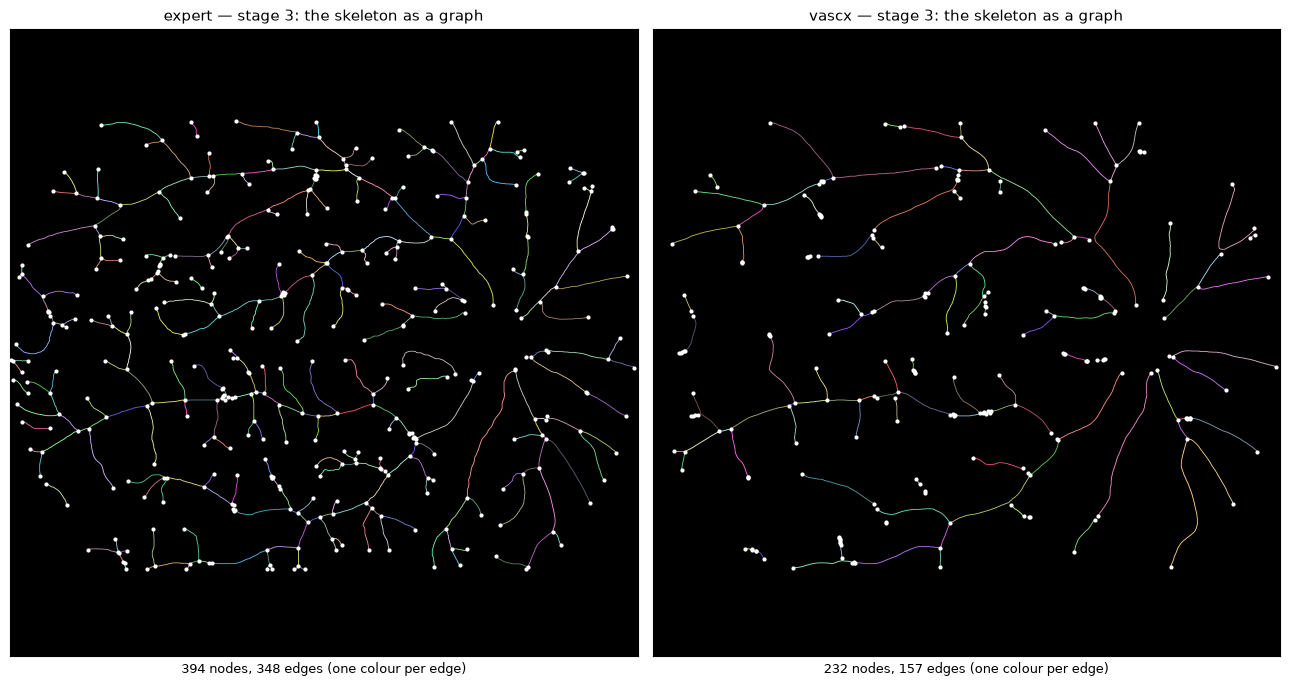

In [5]:
RNG = np.random.default_rng(0)


def show_graph(axis, name, layer):
    axis.imshow(np.zeros((SIDE, SIDE, 3), dtype=np.uint8))
    for source, target in layer.graph.edges():
        points = layer.graph[source][target]["pts"]
        axis.plot(points[:, 1], points[:, 0], linewidth=0.6, color=RNG.random(3) * 0.7 + 0.3)
    nodes = np.array([layer.graph.nodes[n]["o"] for n in layer.graph.nodes()])
    axis.scatter(nodes[:, 1], nodes[:, 0], s=4, c="white", zorder=3)
    axis.set_xlabel(
        f"{layer.graph.number_of_nodes()} nodes, {layer.graph.number_of_edges()} edges "
        f"(one colour per edge)",
        fontsize=9,
    )


panels("stage 3: the skeleton as a graph", show_graph)

## 4 and 5. Trees, direction, and spur removal

`make_trees` takes **one tree per connected component**, rooted at whichever degree-1 node is
nearest the disc centre. A depth-first walk then directs every edge away from its root, and
`correct_digraph(threshold=10)` deletes segments under 10 px and merges the two edges either side
of the node it removed.

**Nothing here bridges a gap.** A component that does not touch another stays its own tree for
ever — which is the finding in
[vessel tracing](../../docs/biomarkers/vessel-tracing.md) §3.2.1, and the reason the tree count
below is in the dozens rather than one or two.

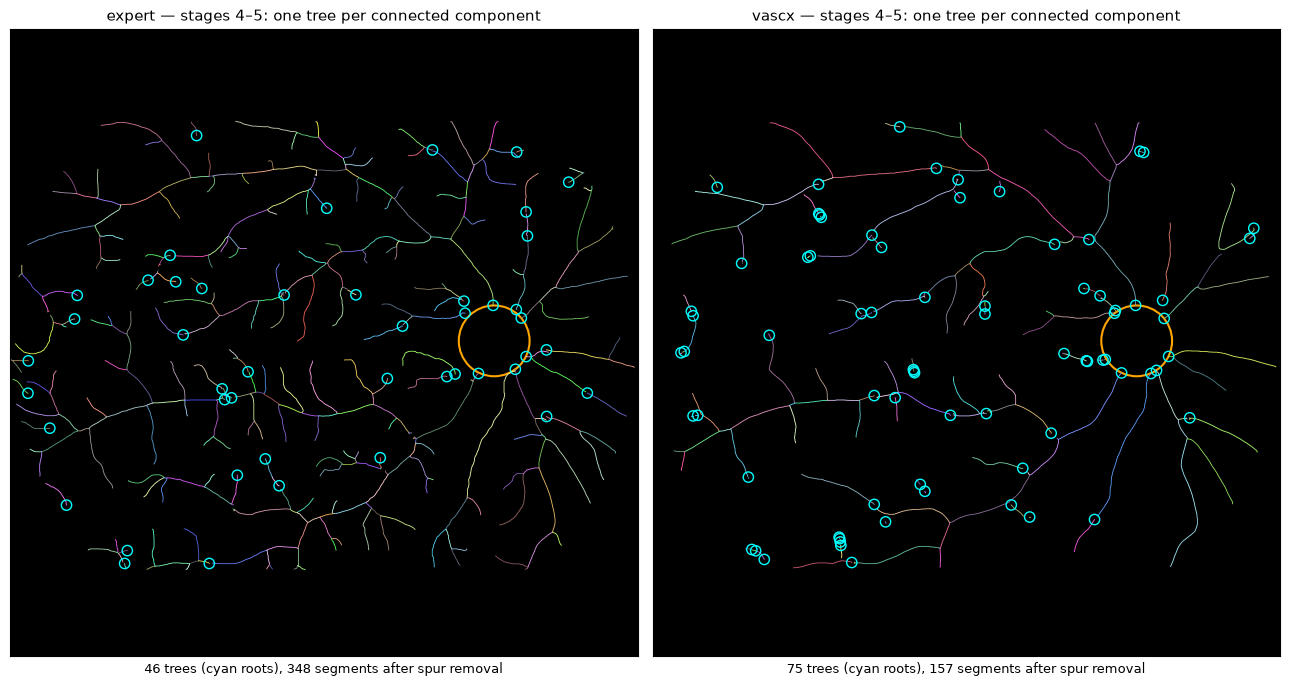

A single retina, and neither tracing finds one artery tree:
  expert   46 trees from  348 segments
  vascx    75 trees from  157 segments


In [6]:
def show_trees(axis, name, layer):
    axis.imshow(np.zeros((SIDE, SIDE, 3), dtype=np.uint8))
    for segment in layer.segments:
        points = np.asarray(segment.skeleton)
        axis.plot(points[:, 1], points[:, 0], linewidth=0.6, color=RNG.random(3) * 0.7 + 0.3)
    roots = np.array([layer.graph.nodes[n]["o"] for n in layer.trees])
    axis.scatter(roots[:, 1], roots[:, 0], s=55, facecolors="none", edgecolors="cyan", zorder=4)
    circle = plt.Circle((DISC_X, DISC_Y), DISC_R, fill=False, color="orange", linewidth=1.5)
    axis.add_patch(circle)
    axis.set_xlabel(
        f"{len(layer.trees)} trees (cyan roots), {len(layer.segments)} segments after spur removal",
        fontsize=9,
    )


panels("stages 4–5: one tree per connected component", show_trees)

print("A single retina, and neither tracing finds one artery tree:")
for name, layer in LAYERS.items():
    print(f"  {name:7s} {len(layer.trees):3d} trees from {len(layer.segments):4d} segments")

## 6. Node types

Each node becomes a `Bifurcation`, an `Endpoint` or a plain `Node`, from its in- and out-degree.
Bifurcation angles are measured here; endpoints are what a severed vessel adds two of.

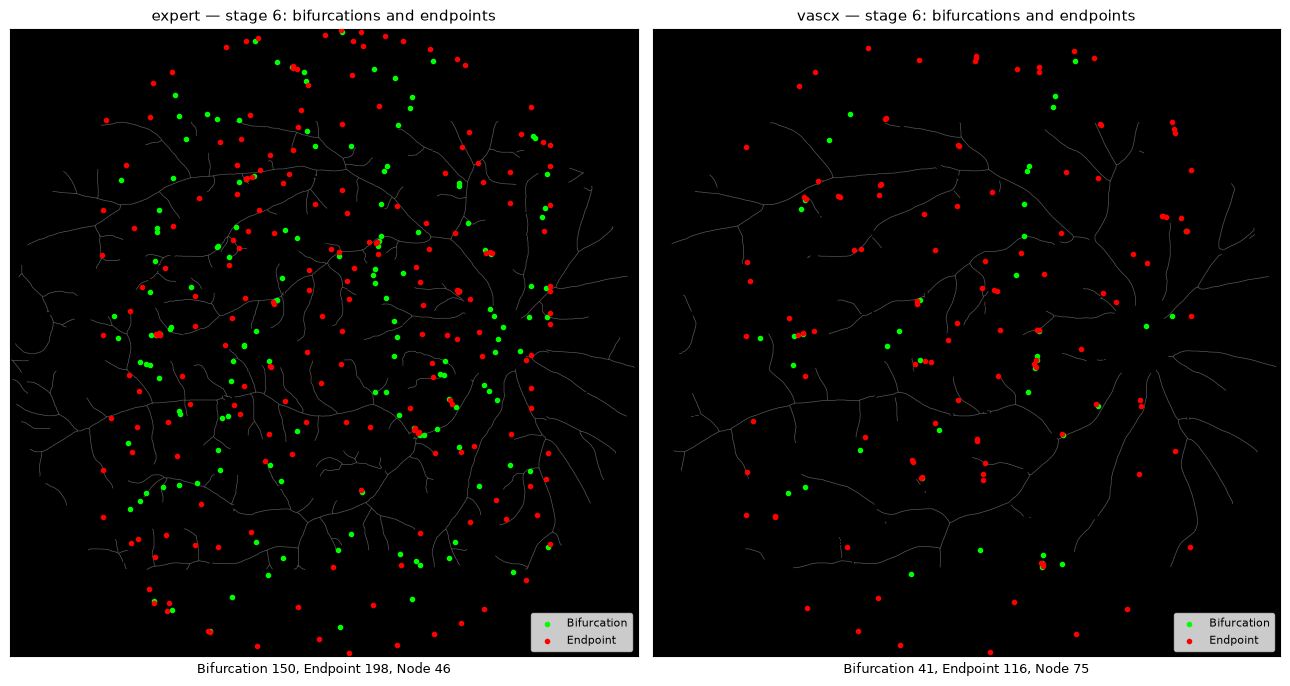

In [7]:
def kinds(layer):
    counted = {}
    for node in layer.nodes:
        counted[type(node).__name__] = counted.get(type(node).__name__, 0) + 1
    return counted


def show_nodes(axis, name, layer):
    axis.imshow(np.zeros((SIDE, SIDE, 3), dtype=np.uint8))
    for segment in layer.segments:
        points = np.asarray(segment.skeleton)
        axis.plot(points[:, 1], points[:, 0], linewidth=0.5, color="#555555")
    for kind, colour in (("Bifurcation", "lime"), ("Endpoint", "red")):
        found = [n for n in layer.nodes if type(n).__name__ == kind]
        if found:
            points = np.array([(n.position.x, n.position.y) for n in found])
            axis.scatter(points[:, 1], points[:, 0], s=9, c=colour, zorder=3, label=kind)
    axis.legend(fontsize=8, loc="lower right")
    axis.set_xlabel(", ".join(f"{k} {v}" for k, v in sorted(kinds(layer).items())), fontsize=9)


panels("stage 6: bifurcations and endpoints", show_nodes)

## 7. The spline — one segment, up close

A cubic smoothing spline is fitted per segment and **everything curved is measured on it**: arc
length, curvature, and the perpendiculars the diameters are sampled along. The skeleton is a
staircase of integer pixels; the spline is what makes a derivative meaningful.

The panel below is the longest segment of the expert's artery map, at full zoom.

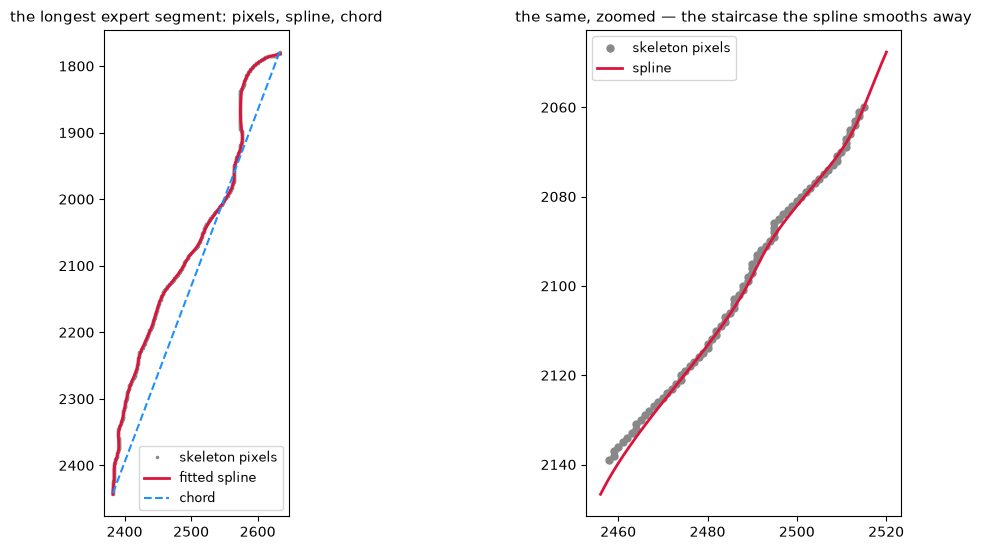

arc length (skeleton steps)   783.58 px
arc length (on the spline)    738.29 px
chord                         709.86 px

τ1 from the skeleton          1.1039
τ1 from the spline            1.0401  <- VascX's default

The staircase is the difference. A skeleton counts a diagonal step as √2 where the curve
through it is shorter, so `segment.length` overstates the arc — here by about 6%, which
lands directly on τ1. `LengthMeasure.Splines` is the constructor default, so the shipped
columns use the lower number. `segment.length` is still what the spur threshold in
`correct_digraph` and the `agg_length` weighting in `_build_vessels` are measured with.


In [8]:
LONGEST = max(LAYERS["expert"].segments, key=lambda s: s.length)
spline = LONGEST.get_spline()
points = np.asarray(LONGEST.skeleton, dtype=float)
curve = np.stack([spline.get_point(t) for t in np.linspace(0, 1, 400)])

figure, axes = plt.subplots(1, 2, figsize=(13, 5.6))
axes[0].plot(points[:, 1], points[:, 0], ".", markersize=3, color="#888888", label="skeleton pixels")
axes[0].plot(curve[:, 1], curve[:, 0], "-", linewidth=2, color="crimson", label="fitted spline")
axes[0].plot(
    [points[0, 1], points[-1, 1]], [points[0, 0], points[-1, 0]],
    "--", color="dodgerblue", linewidth=1.5, label="chord",
)
axes[0].invert_yaxis()
axes[0].set_aspect("equal")
axes[0].legend(fontsize=9)
axes[0].set_title("the longest expert segment: pixels, spline, chord", fontsize=11)

span = 40
middle = len(points) // 2
axes[1].plot(points[middle - span : middle + span, 1], points[middle - span : middle + span, 0],
             "o", markersize=5, color="#888888", label="skeleton pixels")
near = np.stack([spline.get_point(t) for t in np.linspace(0.42, 0.58, 300)])
axes[1].plot(near[:, 1], near[:, 0], "-", linewidth=2, color="crimson", label="spline")
axes[1].invert_yaxis()
axes[1].set_aspect("equal")
axes[1].legend(fontsize=9)
axes[1].set_title("the same, zoomed — the staircase the spline smooths away", fontsize=11)
figure.tight_layout()
plt.show()

print(f"arc length (skeleton steps) {LONGEST.length:8.2f} px")
print(f"arc length (on the spline)  {spline.length():8.2f} px")
print(f"chord                       {LONGEST.chord_length:8.2f} px")
print()
print(f"τ1 from the skeleton        {LONGEST.length / LONGEST.chord_length:8.4f}")
print(f"τ1 from the spline          {spline.length() / LONGEST.chord_length:8.4f}  <- VascX's default")
print()
print("The staircase is the difference. A skeleton counts a diagonal step as √2 where the curve\n"
      "through it is shorter, so `segment.length` overstates the arc — here by about 6%, which\n"
      "lands directly on τ1. `LengthMeasure.Splines` is the constructor default, so the shipped\n"
      "columns use the lower number. `segment.length` is still what the spur threshold in\n"
      "`correct_digraph` and the `agg_length` weighting in `_build_vessels` are measured with.")

### 7.1 `error_fraction` does not change the spline

`get_spline(error_fraction=...)` reads as the knob that controls smoothing, and VascX's own
tortuosity code sets it to **0.25 for curvature and inflections** against 0.05 for everything else
— `_resolved_spline_error_fraction`, which exists only to make that distinction.

*Our finding, 2026-10-03:* it has no effect. `SplineInterpolation.__init__` computes
`self.smoothing = error_fraction * self.total_distance` and then **never reads it**; the value
actually passed to `UnivariateSpline` is `s = sigma_sq * len(self.points)`, derived from the pixel
step variance alone. The cell below fits the same segment both ways.

In [9]:
loose = LONGEST.get_spline(error_fraction=0.25)
tight = LONGEST.get_spline(error_fraction=0.05)

print(f"the two objects differ:            {loose is not tight}")
print(f"their stored `smoothing` differs:  {loose.smoothing:.2f} vs {tight.smoothing:.2f}")
print(f"the `s` actually fitted is equal:  "
      f"{np.isclose(loose.y_spline.get_residual(), tight.y_spline.get_residual())}")
print(f"identical curve:                   "
      f"{np.allclose([loose.get_point(t) for t in np.linspace(0, 1, 50)],
                     [tight.get_point(t) for t in np.linspace(0, 1, 50)])}")
print(f"identical curvatures:              {np.allclose(loose.curvatures(), tight.curvatures())}")
print("\nSo VascX's curvature is not smoothed five times harder than its arc length, as its own"
      "\ncode reads. Both use the same fit.")

the two objects differ:            True
their stored `smoothing` differs:  195.90 vs 39.18
the `s` actually fitted is equal:  True
identical curve:                   True
identical curvatures:              True

So VascX's curvature is not smoothed five times harder than its arc length, as its own
code reads. Both use the same fit.


## 8. Resolved vessels — segments merged across bifurcations

`_build_vessels` walks out from each root and, at every bifurcation, continues the **vessel** along
the daughter with the largest diameter-weighted `agg_value`, merging the remaining daughters as
vessels of their own. This is what "resolved segment" means, and it is the unit a *per-vessel*
biomarker uses.

It merges across junctions. It never merges across a gap.

/Users/staskh/Pheno/fundus-atlas/.atlas_code/vascx/vascx/shared/segment.py:94: UserWarning: Exception when using splines for diameter calculation, falling back to retipy.
  warnings.warn(
/Users/staskh/Pheno/fundus-atlas/.atlas_code/vascx/vascx/shared/segment.py:94: UserWarning: Exception when using splines for diameter calculation, falling back to retipy.
  warnings.warn(
/Users/staskh/Pheno/fundus-atlas/.atlas_code/vascx/vascx/shared/segment.py:94: UserWarning: Exception when using splines for diameter calculation, falling back to retipy.
  warnings.warn(
/Users/staskh/Pheno/fundus-atlas/.atlas_code/vascx/vascx/shared/segment.py:94: UserWarning: Exception when using splines for diameter calculation, falling back to retipy.
  warnings.warn(


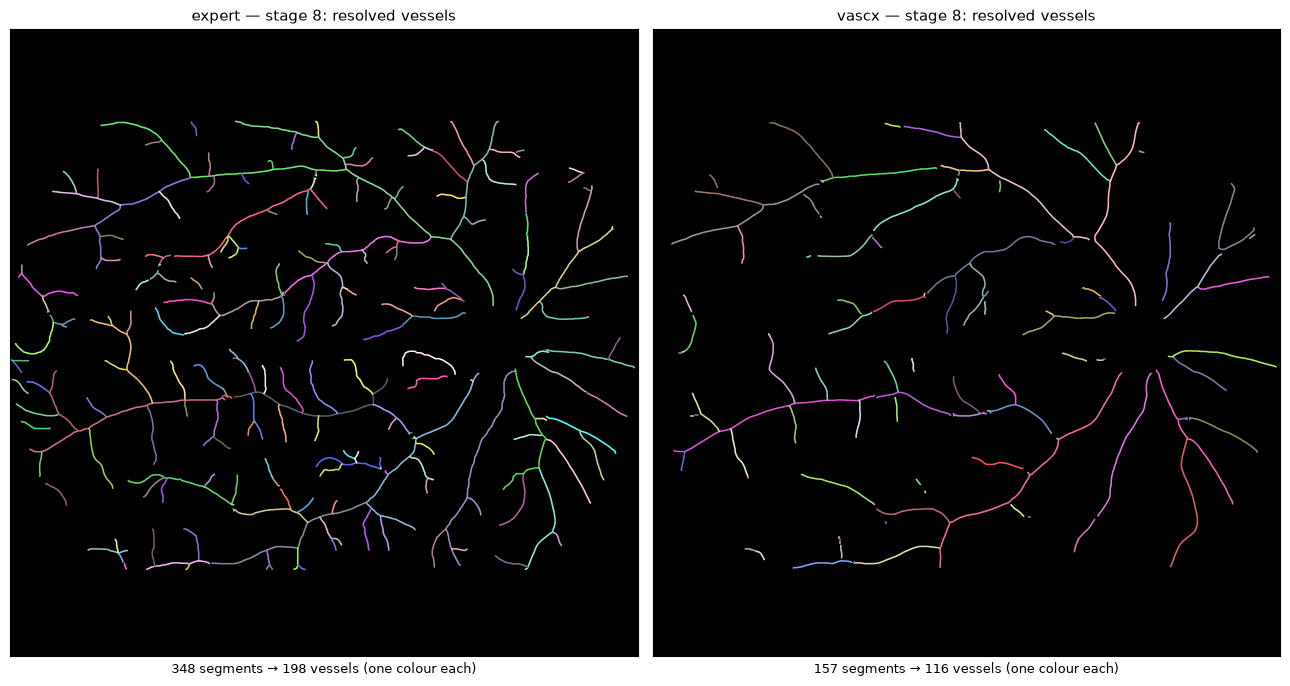

expert  198 vessels | longest  1863.8 px =  9.28 mm | median  142.0 px
vascx   116 vessels | longest  1592.1 px =  7.93 mm | median   92.1 px


In [10]:
def show_vessels(axis, name, layer):
    axis.imshow(np.zeros((SIDE, SIDE, 3), dtype=np.uint8))
    for vessel in layer.resolved_segments:
        pts = np.asarray(vessel.skeleton)
        axis.plot(pts[:, 1], pts[:, 0], linewidth=1.1, color=RNG.random(3) * 0.7 + 0.3)
    axis.set_xlabel(
        f"{len(layer.segments)} segments → {len(layer.resolved_segments)} vessels "
        f"(one colour each)",
        fontsize=9,
    )


panels("stage 8: resolved vessels", show_vessels)

for name, layer in LAYERS.items():
    lengths = sorted((v.length for v in layer.resolved_segments), reverse=True)
    print(f"{name:7s} {len(layer.resolved_segments):3d} vessels | "
          f"longest {lengths[0]:7.1f} px = {lengths[0] * UM_PER_PX / 1000:5.2f} mm | "
          f"median {np.median(lengths):6.1f} px")

## 9. Tortuosity, by hand and by VascX

Three measures, all on the same resolved vessels:

- **Distance ratio** — arc length over chord length, 1 for a straight vessel. The arc comes off
  the **spline** by default (`LengthMeasure.Splines`), not off the skeleton — see 7.
- **Curvature** — the mean of κ sampled along the spline, **multiplied by the disc-fovea
  distance**, which makes it dimensionless (the finding on
  [the project page](../../docs/projects/vascx.md) §8.2).
- **Inflections** — how many times the sign of the curvature changes.

The first panel shows the five most tortuous vessels with their chords, so arc-over-chord is
visible rather than only tabulated. The second plots κ along the single most tortuous one.

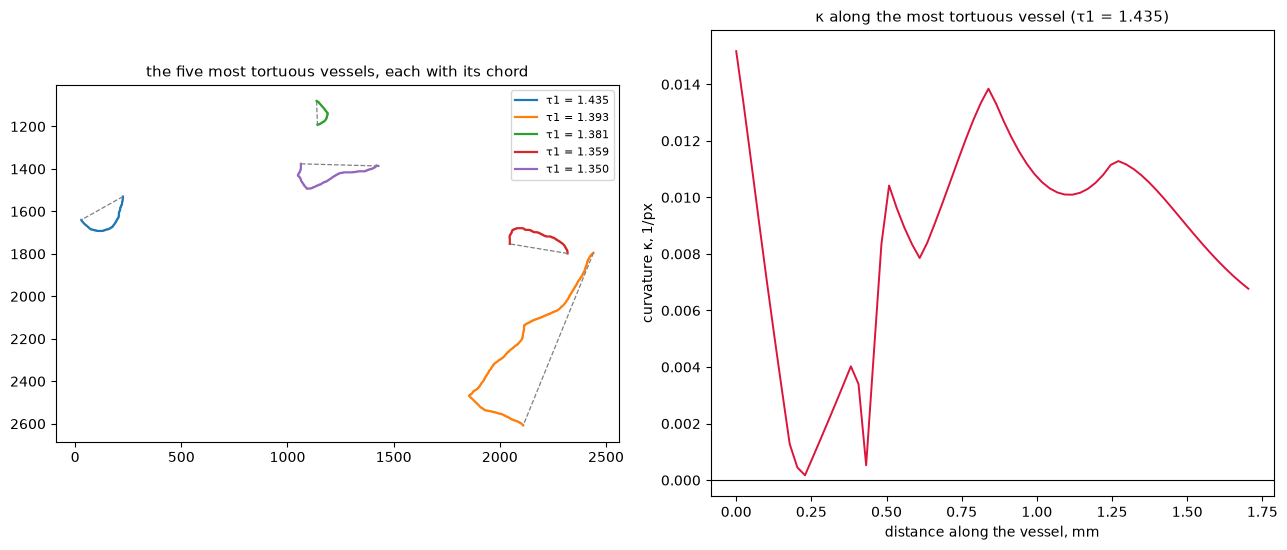

mean κ over the spline      0.008579 /px
disc-fovea distance         1868.7 px
VascX's curvature tortuosity 16.0322 (dimensionless — κ × a length)
inflection points           5


In [11]:
layer = LAYERS["expert"]
def tau1(vessel) -> float:
    """Arc over chord, with the arc taken off the spline — `LengthMeasure.Splines`, the default."""
    curve = vessel.get_spline()
    return curve.length() / vessel.chord_length if curve else np.nan


ranked = sorted(
    (v for v in layer.resolved_segments
     if v.chord_length > 1 and len(v.skeleton) > 60 and v.get_spline()),
    key=tau1,
    reverse=True,
)
top = ranked[:5]

figure, axes = plt.subplots(1, 2, figsize=(13, 5.6))
for vessel in top:
    pts = np.asarray(vessel.skeleton)
    axes[0].plot(pts[:, 1], pts[:, 0], linewidth=1.6, label=f"τ1 = {tau1(vessel):.3f}")
    axes[0].plot([pts[0, 1], pts[-1, 1]], [pts[0, 0], pts[-1, 0]], "--", linewidth=0.9, color="grey")
axes[0].invert_yaxis()
axes[0].set_aspect("equal")
axes[0].legend(fontsize=8)
axes[0].set_title("the five most tortuous vessels, each with its chord", fontsize=11)

worst = top[0]
curve = worst.get_spline()
kappa = np.asarray(curve.curvatures())
along = np.linspace(0, curve.total_distance * UM_PER_PX / 1000, len(kappa))
axes[1].plot(along, kappa, linewidth=1.4, color="crimson")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("distance along the vessel, mm")
axes[1].set_ylabel("curvature κ, 1/px")
axes[1].set_title(f"κ along the most tortuous vessel (τ1 = {tau1(worst):.3f})", fontsize=11)
figure.tight_layout()
plt.show()

print(f"mean κ over the spline      {np.mean(kappa):.6f} /px")
print(f"disc-fovea distance         {layer.retina.disc_fovea_distance:.1f} px")
print(f"VascX's curvature tortuosity {np.mean(kappa) * layer.retina.disc_fovea_distance:.4f} "
      f"(dimensionless — κ × a length)")
print(f"inflection points           {len(curve.inflection_points(every=10))}")

### 9.1 The same three, through VascX's own feature objects

By hand above; by `Tortuosity` here, so the arithmetic can be checked against the thing that
actually runs. These are the objects a shipped feature set is assembled from.

In [12]:
from vascx.fundus.features.tortuosity import (  # noqa: E402
    Tortuosity,
    TortuosityMeasure,
    TortuosityMode,
)

rows = []
for name, one in LAYERS.items():
    for measure in (TortuosityMeasure.Distance, TortuosityMeasure.Curvature,
                    TortuosityMeasure.Inflections):
        for mode in (TortuosityMode.Segments, TortuosityMode.Vessels):
            feature = Tortuosity(mode=mode, measure=measure)
            try:
                value = feature.compute(one)
            except Exception as failure:  # noqa: BLE001 — a WIP notebook reports rather than dies
                value = f"{type(failure).__name__}"
            rows.append({"map": name, "measure": measure.value, "mode": mode.value, "value": value})

import pandas as pd  # noqa: E402

table = pd.DataFrame(rows).pivot(index=["measure", "mode"], columns="map", values="value")
print(table.to_string())
print("\n`dist` is arc over chord; `curv` is κ̄ × the disc-fovea distance; `infl` is a count.")
print("Per `segments` the population is stage 5's; per `vessels` it is stage 8's.")

/Users/staskh/Pheno/fundus-atlas/.atlas_code/vascx/vascx/shared/segment.py:94: UserWarning: Exception when using splines for diameter calculation, falling back to retipy.
  warnings.warn(
/Users/staskh/Pheno/fundus-atlas/.atlas_code/vascx/vascx/shared/segment.py:94: UserWarning: Exception when using splines for diameter calculation, falling back to retipy.
  warnings.warn(
/Users/staskh/Pheno/fundus-atlas/.atlas_code/vascx/vascx/shared/segment.py:94: UserWarning: Exception when using splines for diameter calculation, falling back to retipy.
  warnings.warn(
/Users/staskh/Pheno/fundus-atlas/.atlas_code/vascx/vascx/shared/segment.py:94: UserWarning: Exception when using splines for diameter calculation, falling back to retipy.
  warnings.warn(


map                  expert      vascx
measure mode                          
curv    segments  17.675266  11.755579
        vessels   20.188133  13.261821
dist    segments   1.015880   1.014869
        vessels    1.033916   1.020893
infl    segments   2.000000   3.000000
        vessels    4.000000   5.000000

`dist` is arc over chord; `curv` is κ̄ × the disc-fovea distance; `infl` is a count.
Per `segments` the population is stage 5's; per `vessels` it is stage 8's.


## 10. What to take from this

- **The segment and the vessel are different populations**, and every tortuosity number depends on
  which one it was pooled over — stage 5's count against stage 8's, in section 8.
- **A tree is a connected component, not an artery.** Dozens of them on one retina, because the
  mask is broken wherever a vein crossed and nothing rejoins it.
- **`error_fraction` is inert** (7.1), so VascX's curvature is not smoothed as its own code reads.
- **The curvature measure is dimensionless**, being κ multiplied by the disc-fovea distance — and on
  a photograph with no annotated fovea, that length is a convention somebody supplied.

Nothing here is a benchmark result. The measured comparison of VascX against the expert's map is
[vascx-features-on-photographs.ipynb](vascx-features-on-photographs.ipynb); this notebook is for
watching the machinery that produces it.